# Monte Carlo Path Integrals & a QKD Eavesdropping Estimator

Two places where sampling randomness, not direct integration, is the right
computational tool -- and two places you can check the sampler against a
closed-form answer.

**Part A.** Feynman's path integral writes the Schrodinger propagator as a sum
over all paths. In real time that sum is a wild oscillatory integral; Wick-
rotating to imaginary time turns it into a real, decaying weight
$e^{-S_E/\hbar}$ that a Metropolis random walk can actually sample -- this is
**Path Integral Monte Carlo (PIMC)**, the real technique used to compute
thermal/ground-state properties of quantum systems too hard to diagonalize by
hand. We validate it on the one system with an exact answer: the harmonic
oscillator.

**Part B.** BB84 quantum key distribution's core security claim -- an
eavesdropper measuring in the wrong basis introduces detectable errors -- has
a clean analytic prediction (25% QBER under intercept-resend). We estimate it
by direct Monte Carlo simulation of the protocol and check the two agree.

Builds on `dgs/path_integral_qkd.py` and `dgs/qubits.py`. NumPy only (no SciPy
on this Python); an optional torch-accelerated PIMC sampler exists in the
module for GPU use but isn't required here.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import path_integral_qkd as pq

plt.rcParams["figure.dpi"] = 110
print("numpy", np.__version__)


numpy 2.4.4


## A1. Warm-up: the path-integral composition law (no Monte Carlo yet)

Before sampling anything, check the identity any path integral must satisfy:
splitting a time interval in two and integrating out the midpoint must
reproduce the one-step propagator. In **imaginary time** the free-particle
kernel is a real, decaying Gaussian, so a plain grid integral nails this
to machine precision. In real time the same kernel is a pure, non-decaying
phase -- which is exactly why real-time path-integral Monte Carlo is hard,
and why PIMC works in imaginary time instead.


In [2]:
tau, x0, xf = 1.0, 0.0, 2.0
K_two_slice, K_analytic = pq.free_particle_propagator_two_slice_check(xf, x0, tau)
print(f"two-slice integral : {K_two_slice:.10f}")
print(f"one-slice analytic : {K_analytic:.10f}")
print(f"relative error     : {abs(K_two_slice - K_analytic)/abs(K_analytic):.2e}")


two-slice integral : 0.0539909665
one-slice analytic : 0.0539909665
relative error     : 2.57e-16


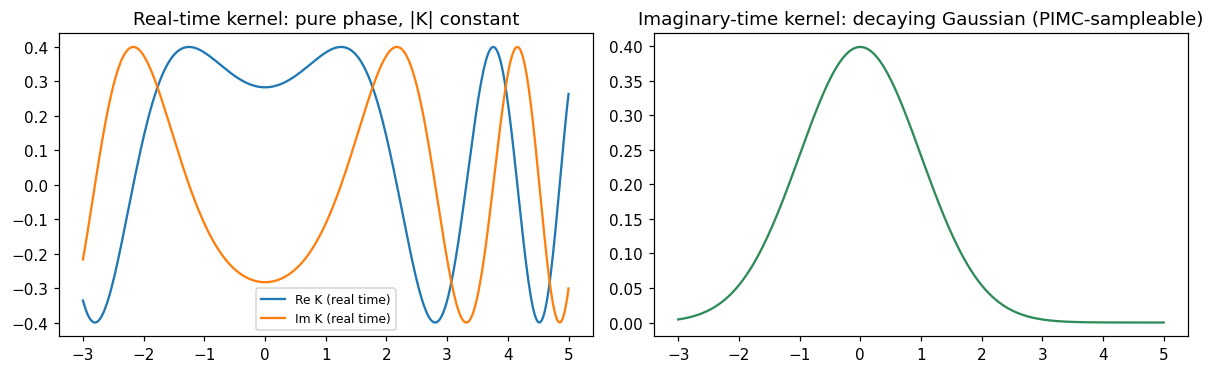

In [3]:
x_grid = np.linspace(-3, 5, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

K_real = pq.free_particle_propagator_analytic(x_grid, x0, tau)
axes[0].plot(x_grid, K_real.real, label="Re K (real time)")
axes[0].plot(x_grid, K_real.imag, label="Im K (real time)")
axes[0].set_title("Real-time kernel: pure phase, |K| constant")
axes[0].legend(fontsize=8)

K_euc = pq.free_particle_propagator_euclidean_analytic(x_grid, x0, tau)
axes[1].plot(x_grid, K_euc, color="seagreen")
axes[1].set_title("Imaginary-time kernel: decaying Gaussian (PIMC-sampleable)")
fig.tight_layout()
plt.show()


## A2. PIMC for the quantum harmonic oscillator

A ring of $n_{\text{slices}}$ imaginary-time beads, Metropolis-updated against
the discretized Euclidean action, samples the thermal path-integral measure.
We estimate $\langle x^2\rangle$ and $\langle H\rangle$ and compare against
the *exact* QHO thermal values

$$\langle H\rangle = \frac{\hbar\omega}{2}\coth\!\left(\frac{\hbar\omega\beta}{2}\right), \qquad
\langle x^2\rangle = \frac{\hbar}{2m\omega}\coth\!\left(\frac{\hbar\omega\beta}{2}\right).$$


In [4]:
beta = 2.0
result = pq.pimc_harmonic_oscillator(beta=beta, n_slices=16, n_sweeps=20000,
                                      burn_in=2000, step_size=1.0, seed=3)
for k, v in result.items():
    print(f"{k:14s} = {v:.6f}")


x2_mc          = 0.707293
x2_mc_err      = 0.004759
H_mc           = 0.691405
H_mc_err       = 0.009439
x2_analytic    = 0.656518
H_analytic     = 0.656518


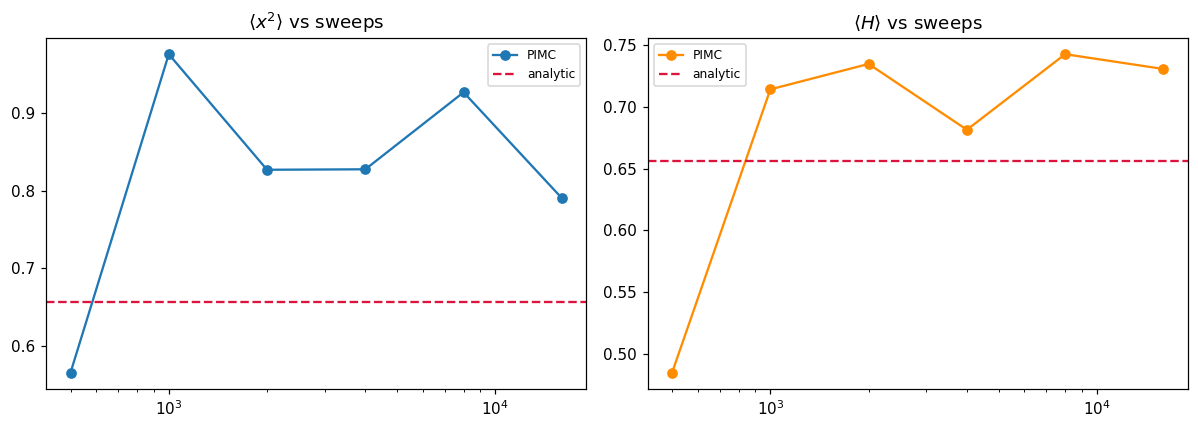

In [5]:
# convergence vs number of Metropolis sweeps (fixed slicing)
sweep_counts = [500, 1000, 2000, 4000, 8000, 16000]
x2_trace, H_trace = [], []
for ns in sweep_counts:
    r = pq.pimc_harmonic_oscillator(beta=beta, n_slices=16, n_sweeps=ns, burn_in=500,
                                     step_size=1.0, seed=3)
    x2_trace.append(r["x2_mc"]); H_trace.append(r["H_mc"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(sweep_counts, x2_trace, "o-", label="PIMC")
axes[0].axhline(result["x2_analytic"], ls="--", color="crimson", label="analytic")
axes[0].set_xscale("log"); axes[0].set_title(r"$\langle x^2 \rangle$ vs sweeps"); axes[0].legend(fontsize=8)

axes[1].plot(sweep_counts, H_trace, "o-", color="darkorange", label="PIMC")
axes[1].axhline(result["H_analytic"], ls="--", color="crimson", label="analytic")
axes[1].set_xscale("log"); axes[1].set_title(r"$\langle H \rangle$ vs sweeps"); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


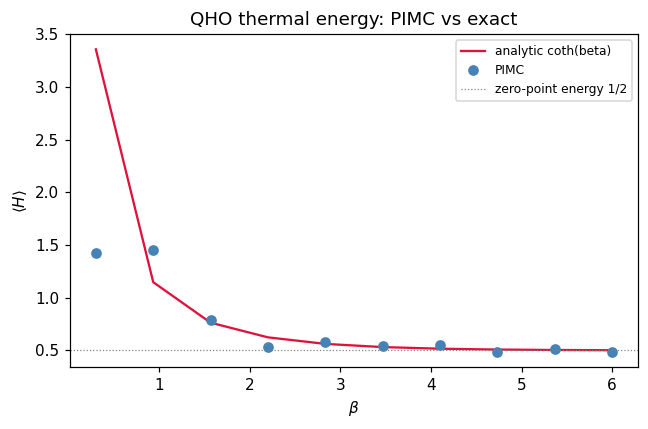

In [6]:
# thermal energy vs beta: PIMC should trace the coth() curve, including the
# T->0 plateau at the zero-point energy hbar*omega/2
betas = np.linspace(0.3, 6.0, 10)
H_mc_vals, H_an_vals = [], []
for b in betas:
    r = pq.pimc_harmonic_oscillator(beta=b, n_slices=16, n_sweeps=6000, burn_in=800,
                                     step_size=1.0, seed=5)
    H_mc_vals.append(r["H_mc"]); H_an_vals.append(r["H_analytic"])

plt.figure(figsize=(6, 4))
plt.plot(betas, H_an_vals, "-", color="crimson", label="analytic coth(beta)")
plt.plot(betas, H_mc_vals, "o", color="steelblue", label="PIMC")
plt.axhline(0.5, ls=":", color="gray", lw=0.8, label="zero-point energy 1/2")
plt.xlabel(r"$\beta$"); plt.ylabel(r"$\langle H \rangle$")
plt.title("QHO thermal energy: PIMC vs exact")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## B. BB84 intercept-resend: Monte Carlo QBER vs the analytic 25%

Eve intercepts every photon, measures in a random basis, and resends her
(possibly wrong) result. When her basis happens to differ from Alice's
(probability 1/2), she collapses the state and Bob's later measurement
becomes a coin flip even when his basis matches Alice's -- giving a quantum
bit error rate of $\tfrac12 \times \tfrac12 = 25\%$ on the sifted key, the
textbook bound that makes intercept-resend detectable.


In [7]:
n_bits = 200_000
clean = pq.bb84_intercept_resend_qber(n_bits=n_bits, eavesdrop=False, seed=0)
eve   = pq.bb84_intercept_resend_qber(n_bits=n_bits, eavesdrop=True, seed=0)

print("No eavesdropper:", clean)
print("Intercept-resend:", eve)


No eavesdropper: {'n_bits': 200000, 'n_sifted': 99883, 'qber_mc': 0.0, 'qber_analytic': 0.0}
Intercept-resend: {'n_bits': 200000, 'n_sifted': 99793, 'qber_mc': 0.2514705440261341, 'qber_analytic': 0.25}


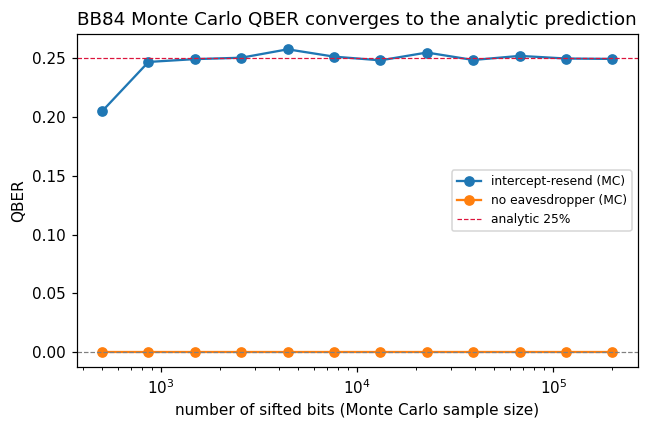

In [8]:
ns = np.geomspace(500, 200_000, 12).astype(int)
qber_eve, qber_clean = [], []
for n in ns:
    qber_eve.append(pq.bb84_intercept_resend_qber(n_bits=int(n), eavesdrop=True, seed=1)["qber_mc"])
    qber_clean.append(pq.bb84_intercept_resend_qber(n_bits=int(n), eavesdrop=False, seed=1)["qber_mc"])

plt.figure(figsize=(6, 4))
plt.semilogx(ns, qber_eve, "o-", label="intercept-resend (MC)")
plt.semilogx(ns, qber_clean, "o-", label="no eavesdropper (MC)")
plt.axhline(0.25, ls="--", color="crimson", lw=0.8, label="analytic 25%")
plt.axhline(0.0, ls="--", color="gray", lw=0.8)
plt.xlabel("number of sifted bits (Monte Carlo sample size)")
plt.ylabel("QBER")
plt.title("BB84 Monte Carlo QBER converges to the analytic prediction")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Summary

`free_particle_propagator_two_slice_check` confirms the path-integral
composition law to machine precision in imaginary time, and explains exactly
why real-time path-integral Monte Carlo is avoided in practice. PIMC then
estimates the harmonic oscillator's thermal $\langle x^2\rangle$ and
$\langle H\rangle$ within the discretization (Trotter) error you'd expect,
converging onto the exact $\coth$ curve as sweeps increase. Separately, a
direct Monte Carlo simulation of BB84 reproduces the textbook 25%
intercept-resend QBER -- the same "simulate it, then check it against the
closed form" methodology applied to two different pieces of physics.
